# Audio IIR Filter Design

Design Chebyshev Type I IIR bandpass filters for the SSB audio chain (20 kHz DSP rate).

Pipeline order:
1. **High-pass filter** — remove DC and sub-audio components below 200 Hz
2. **Compression** — dynamic range compression (algorithm to be added)
3. **Low-pass filter** — limit audio bandwidth to 2800 Hz for SSB

Coefficients are generated as single-precision `f32` in Direct Form II Transposed
(CMSIS-DSP biquad convention: `[b0, b1, b2, -a1, -a2]` per section, normalised by `a0`).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

## Filter parameters

The audio chain operates at 20 kHz (after 10:1 decimation from the 200 kHz ADC rate).
Both filters are 4th-order Chebyshev Type I with 0.3 dB passband ripple.

In [ ]:
FS   = 20_000   # DSP sample rate [Hz] — must match DSP_RATE_HZ in src/config.rs
FN   = FS / 2   # Nyquist frequency [Hz]

F_LOW  =   200  # high-pass cutoff [Hz]
F_HIGH = 2_800  # low-pass  cutoff [Hz]

ORDER  = 4      # filter order (yields ORDER/2 = 2 biquad sections per filter)
RIPPLE = 0.3    # passband ripple [dB]

## Filter design

In [ ]:
sos_hp = sig.cheby1(ORDER, RIPPLE, F_LOW  / FN, btype='highpass', output='sos')
sos_lp = sig.cheby1(ORDER, RIPPLE, F_HIGH / FN, btype='lowpass',  output='sos')

print(f'High-pass: {sos_hp.shape[0]} biquad sections')
print(f'Low-pass:  {sos_lp.shape[0]} biquad sections')

High-pass: 2 biquad sections
Low-pass:  2 biquad sections


## Frequency response

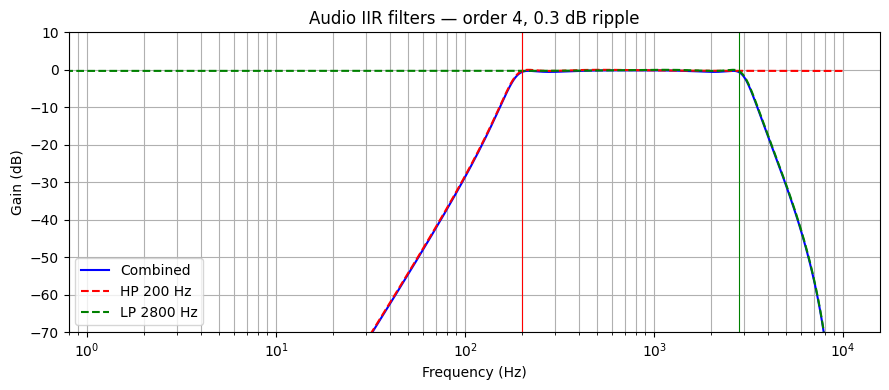

In [ ]:
sos_combined = np.vstack((sos_hp, sos_lp))

w,   h   = sig.freqz_sos(sos_combined, worN=8000, fs=FS)
whp, hhp = sig.freqz_sos(sos_hp,       worN=8000, fs=FS)
wlp, hlp = sig.freqz_sos(sos_lp,       worN=8000, fs=FS)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(w,   20 * np.log10(np.abs(h)   + 1e-12), 'b',  label='Combined')
ax.semilogx(whp, 20 * np.log10(np.abs(hhp) + 1e-12), 'r--', label=f'HP {F_LOW} Hz')
ax.semilogx(wlp, 20 * np.log10(np.abs(hlp) + 1e-12), 'g--', label=f'LP {F_HIGH} Hz')
ax.axvline(F_LOW,  color='r', lw=0.8)
ax.axvline(F_HIGH, color='g', lw=0.8)
ax.set_title(f'Audio IIR filters — order {ORDER}, {RIPPLE} dB ripple')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Gain (dB)')
ax.set_ylim(-70, 10)
ax.grid(True, which='both')
ax.legend()
plt.tight_layout()
plt.show()

## Rust code generation

Coefficients are converted to `f32` and laid out as `[b0, b1, b2, -a1, -a2]` per biquad
section (normalised by `a0`).  This matches the Direct Form II Transposed convention used
by CMSIS-DSP `arm_biquad_cascade_df2T_f32` and our own Rust biquad implementation.

In [ ]:
def sos_to_rust(sos: np.ndarray, name: str) -> str:
    """Format a scipy SOS array as a Rust [[f32; 5]; N] constant.

    Each row becomes [b0/a0, b1/a0, b2/a0, -a1/a0, -a2/a0] in f32.
    """
    stages = sos.shape[0]
    rows = []
    for b0, b1, b2, a0, a1, a2 in sos:
        c = [float(np.float32(v)) for v in
             [b0/a0, b1/a0, b2/a0, -a1/a0, -a2/a0]]
        rows.append('    [' + ', '.join(f'{v:.10e}' for v in c) + ']')

    upper = name.upper()
    lines = [
        f'/// Number of biquad sections in the {name} filter.',
        f'pub const {upper}_STAGES: usize = {stages};',
        f'',
        f'/// {name.capitalize()} filter coefficients: [[b0, b1, b2, -a1, -a2]; {stages}] in f32.',
        f'/// Direct Form II Transposed, normalised by a0.',
        f'/// Cutoff {F_LOW if name=="highpass" else F_HIGH} Hz, Chebyshev I order {ORDER}, {RIPPLE} dB ripple.',
        f'#[rustfmt::skip]',
        f'pub const {upper}_COEFFS: [[f32; 5]; {upper}_STAGES] = [',
    ] + rows + ['];']
    return '\n'.join(lines)


rust = '\n\n'.join([
    sos_to_rust(sos_hp, 'highpass'),
    sos_to_rust(sos_lp, 'lowpass'),
])
print(rust)

/// Number of biquad sections in the highpass filter.
pub const HIGHPASS_STAGES: usize = 2;

/// Highpass filter coefficients: [[b0, b1, b2, -a1, -a2]; 2] in f32.
/// Direct Form II Transposed, normalised by a0.
/// Cutoff 200 Hz, Chebyshev I order 4, 0.3 dB ripple.
#[rustfmt::skip]
pub const HIGHPASS_COEFFS: [[f32; 5]; HIGHPASS_STAGES] = [
    [8.8843882084e-01, -1.7768776417e+00, 8.8843882084e-01, 1.8572715521e+00, -8.6588841677e-01]
    [1.0000000000e+00, -2.0000000000e+00, 1.0000000000e+00, 1.9743645191e+00, -9.7780704498e-01]
];

/// Number of biquad sections in the lowpass filter.
pub const LOWPASS_STAGES: usize = 2;

/// Lowpass filter coefficients: [[b0, b1, b2, -a1, -a2]; 2] in f32.
/// Direct Form II Transposed, normalised by a0.
/// Cutoff 2800 Hz, Chebyshev I order 4, 0.3 dB ripple.
#[rustfmt::skip]
pub const LOWPASS_COEFFS: [[f32; 5]; LOWPASS_STAGES] = [
    [1.0223765858e-02, 2.0447531715e-02, 1.0223765858e-02, 1.1647846699e+00, -4.0787613392e-01]
    [1.0000000000e+00, 2